**TEMPERATURE DATA (DATA 1)**

In [ ]:
!pip install kaggle --quiet

from google.colab import files
print("Unggah file kaggle.json Anda (dari Kaggle Account > Create New API Token):")
uploaded = files.upload()

!mkdir -p ~/.kaggle
!mv kaggle.json ~/.kaggle/
!chmod 600 ~/.kaggle/kaggle.json

In [2]:
!kaggle competitions list

ref                                                                           deadline             category         reward  teamCount  userHasEntered  
----------------------------------------------------------------------------  -------------------  --------  -------------  ---------  --------------  
https://www.kaggle.com/competitions/passenger-screening-algorithm-challenge   2017-12-15 23:59:00  Featured  1,500,000 Usd        518           False  
https://www.kaggle.com/competitions/zillow-prize-1                            2018-01-10 15:59:00  Featured  1,200,000 Usd       3770           False  
https://www.kaggle.com/competitions/data-science-bowl-2017                    2017-04-12 23:59:00  Featured  1,000,000 Usd       1972           False  
https://www.kaggle.com/competitions/vesuvius-challenge-ink-detection          2023-06-14 23:59:00  Featured  1,000,000 Usd       1249           False  
https://www.kaggle.com/competitions/arc-prize-2026-arc-agi-3                  2026-11-02

In [3]:
!kaggle datasets download -d atulanandjha/temperature-readings-iot-devices

Dataset URL: https://www.kaggle.com/datasets/atulanandjha/temperature-readings-iot-devices
License(s): GNU Lesser General Public License 3.0
100% 1.02M/1.02M [00:00<00:00, 144MB/s]

Archive:  temperature-readings-iot-devices.zip
checkdir:  cannot create extraction directory: data/raw/iot_temp
           No such file or directory


In [4]:
!mkdir -p data/raw/iot_temp
!unzip -o temperature-readings-iot-devices.zip -d data/raw/iot_temp

Archive:  temperature-readings-iot-devices.zip
  inflating: data/raw/iot_temp/IOT-temp.csv  


In [5]:
import pandas as pd

df = pd.read_csv('data/raw/iot_temp/IOT-temp.csv')
df.head()

,id,room_id/id,noted_date,temp,out/in
0,__export__.temp_log_196134_bd201015,Room Admin,08-12-2018 09:30,29,In
1,__export__.temp_log_196131_7bca51bc,Room Admin,08-12-2018 09:30,29,In
2,__export__.temp_log_196127_522915e3,Room Admin,08-12-2018 09:29,41,Out
3,__export__.temp_log_196128_be0919cf,Room Admin,08-12-2018 09:29,41,Out
4,__export__.temp_log_196126_d30b72fb,Room Admin,08-12-2018 09:29,31,In


In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 97606 entries, 0 to 97605
Data columns (total 5 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   id          97606 non-null  object
 1   room_id/id  97606 non-null  object
 2   noted_date  97606 non-null  object
 3   temp        97606 non-null  int64 
 4   out/in      97606 non-null  object
dtypes: int64(1), object(4)
memory usage: 3.7+ MB


In [7]:
df['room_id/id'].unique()

array(['Room Admin'], dtype=object)

In [8]:
df['out/in'].value_counts()

,count
out/in,
Out,77261
In,20345


In [9]:
df['temp'].describe()

,temp
count,97606.000000
mean,35.053931
std,5.699825
min,21.000000
25%,30.000000
50%,35.000000
75%,40.000000
max,51.000000


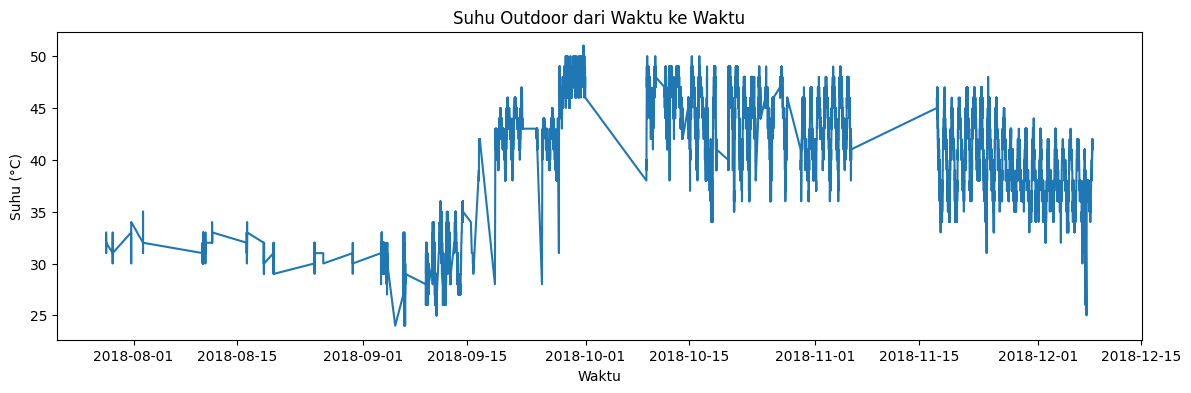

In [12]:
df['noted_date'] = pd.to_datetime(df['noted_date'], format='%d-%m-%Y %H:%M')
df = df.sort_values('noted_date')
df.head()

import matplotlib.pyplot as plt

df_out = df[df['out/in'] == 'Out'].sort_values('noted_date')
plt.figure(figsize=(14,4))
plt.plot(df_out['noted_date'], df_out['temp'])
plt.title('Suhu Outdoor dari Waktu ke Waktu')
plt.xlabel('Waktu')
plt.ylabel('Suhu (°C)')
plt.show()

In [13]:
df_out['gap_minutes'] = df_out['noted_date'].diff().dt.total_seconds() / 60
df_out['gap_minutes'].describe()

,gap_minutes
count,77260.000000
mean,2.480740
std,103.173143
min,0.000000
25%,0.000000
50%,0.000000
75%,1.000000
max,16658.000000


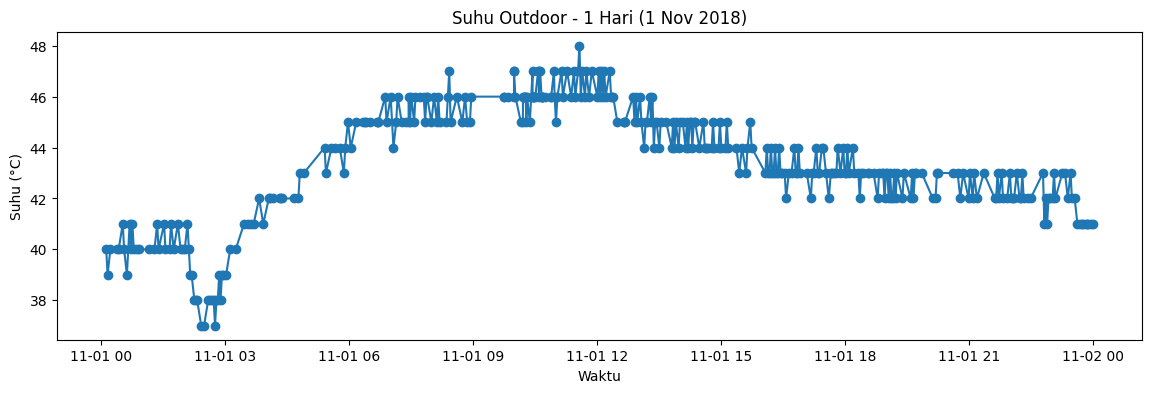

In [14]:
satu_hari = df_out[(df_out['noted_date'] >= '2018-11-01') & (df_out['noted_date'] < '2018-11-02')]
plt.figure(figsize=(14,4))
plt.plot(satu_hari['noted_date'], satu_hari['temp'], marker='o')
plt.title('Suhu Outdoor - 1 Hari (1 Nov 2018)')
plt.xlabel('Waktu')
plt.ylabel('Suhu (°C)')
plt.show()

**LAB DATA (DATA 2)**

In [15]:
!wget http://db.csail.mit.edu/labdata/data.txt.gz
!gunzip data.txt.gz
!mkdir -p data/raw/intel_lab
!mv data.txt data/raw/intel_lab/

--2026-08-02 05:32:53--  http://db.csail.mit.edu/labdata/data.txt.gz
Resolving db.csail.mit.edu (db.csail.mit.edu)... 128.52.128.91
Connecting to db.csail.mit.edu (db.csail.mit.edu)|128.52.128.91|:80... connected.
HTTP request sent, awaiting response... 301 Moved Permanently
Location: https://db.csail.mit.edu/labdata/data.txt.gz [following]
--2026-08-02 05:32:54--  https://db.csail.mit.edu/labdata/data.txt.gz
Connecting to db.csail.mit.edu (db.csail.mit.edu)|128.52.128.91|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 34422518 (33M) [application/x-gzip]
Saving to: ‘data.txt.gz’

data.txt.gz         100%[===================>]  32.83M  28.4MB/s    in 1.2s    

2026-08-02 05:32:55 (28.4 MB/s) - ‘data.txt.gz’ saved [34422518/34422518]



In [17]:
cols = ['date', 'time', 'epoch', 'moteid', 'temperature', 'humidity', 'light', 'voltage']
df_intel = pd.read_csv('data/raw/intel_lab/data.txt', sep=' ', names=cols, header=None)
df_intel.head()

,date,time,epoch,moteid,temperature,humidity,light,voltage
0,2004-03-31,03:38:15.757551,2,1.0,122.1530,-3.91901,11.04,2.03397
1,2004-02-28,00:59:16.02785,3,1.0,19.9884,37.09330,45.08,2.69964
2,2004-02-28,01:03:16.33393,11,1.0,19.3024,38.46290,45.08,2.68742
3,2004-02-28,01:06:16.013453,17,1.0,19.1652,38.80390,45.08,2.68742
4,2004-02-28,01:06:46.778088,18,1.0,19.1750,38.83790,45.08,2.69964


In [23]:
# Filter moteid yang valid (1-54 sesuai spek asli)
df_intel_valid = df_intel[(df_intel['moteid'] >= 1) & (df_intel['moteid'] <= 54)]
print(f"Baris sebelum filter: {len(df_intel)}")
print(f"Baris sesudah filter moteid valid: {len(df_intel_valid)}")

# Cek ulang outlier suhu di data yang moteid-nya valid
outlier_valid = df_intel_valid[(df_intel_valid['temperature'] < 0) | (df_intel_valid['temperature'] > 50)]
print(f"Persentase outlier (moteid valid aja): {len(outlier_valid)/len(df_intel_valid)*100:.2f}%")

Baris sebelum filter: 2313682
Baris sesudah filter moteid valid: 2303290
Persentase outlier (moteid valid aja): 17.72%


**DATA 3**

In [24]:
!kaggle datasets download -d ziya07/smart-manufacturing-iot-cloud-monitoring-dataset
!mkdir -p data/raw/smart_manufacturing
!unzip -o smart-manufacturing-iot-cloud-monitoring-dataset.zip -d data/raw/smart_manufacturing

Dataset URL: https://www.kaggle.com/datasets/ziya07/smart-manufacturing-iot-cloud-monitoring-dataset
License(s): CC0-1.0
100% 1.83M/1.83M [00:00<00:00, 151MB/s]

Archive:  smart-manufacturing-iot-cloud-monitoring-dataset.zip
  inflating: data/raw/smart_manufacturing/smart_manufacturing_data.csv  


In [25]:
df_sm = pd.read_csv('data/raw/smart_manufacturing/smart_manufacturing_data.csv')
df_sm.head()

,timestamp,machine_id,temperature,vibration,humidity,pressure,energy_consumption,machine_status,anomaly_flag,predicted_remaining_life,failure_type,downtime_risk,maintenance_required
0,2025-01-01 00:00:00,39,78.61,28.65,79.96,3.73,2.16,1,0,106,Normal,0.0,0
1,2025-01-01 00:01:00,29,68.19,57.28,35.94,3.64,0.69,1,0,320,Normal,0.0,0
2,2025-01-01 00:02:00,15,98.94,50.20,72.06,1.00,2.49,1,1,19,Normal,1.0,1
3,2025-01-01 00:03:00,43,90.91,37.65,30.34,3.15,4.96,1,1,10,Normal,1.0,1
4,2025-01-01 00:04:00,8,72.32,40.69,56.71,2.68,0.63,2,0,65,Vibration Issue,0.0,1


In [30]:
pd.crosstab(df_sm['anomaly_flag'], df_sm['failure_type'])

failure_type,Electrical Fault,Normal,Overheating,Pressure Drop,Vibration Issue
anomaly_flag,,,,,
0,914,83740,1814,1779,2837
1,100,8159,175,190,292


**DATA 4**

In [34]:
!kaggle datasets download -d boltzmannbrain/nab
!mkdir -p data/raw/nab
!unzip -o nab.zip -d data/raw/nab

Dataset URL: https://www.kaggle.com/datasets/boltzmannbrain/nab
License(s): other
100% 1.64M/1.64M [00:00<00:00, 169MB/s]

Archive:  nab.zip
  inflating: data/raw/nab/README.md  
  inflating: data/raw/nab/artificialNoAnomaly/artificialNoAnomaly/art_daily_no_noise.csv  
  inflating: data/raw/nab/artificialNoAnomaly/artificialNoAnomaly/art_daily_perfect_square_wave.csv  
  inflating: data/raw/nab/artificialNoAnomaly/artificialNoAnomaly/art_daily_small_noise.csv  
  inflating: data/raw/nab/artificialNoAnomaly/artificialNoAnomaly/art_flatline.csv  
  inflating: data/raw/nab/artificialNoAnomaly/artificialNoAnomaly/art_noisy.csv  
  inflating: data/raw/nab/artificialWithAnomaly/artificialWithAnomaly/art_daily_flatmiddle.csv  
  inflating: data/raw/nab/artificialWithAnomaly/artificialWithAnomaly/art_daily_jumpsdown.csv  
  inflating: data/raw/nab/artificialWithAnomaly/artificialWithAnomaly/art_daily_jumpsup.csv  
  inflating: data/raw/nab/artificialWithAnomaly/artificialWithAnomaly/art_daily_

In [35]:
import os
for root, dirs, files in os.walk('data/raw/nab'):
    for f in files[:5]:
        print(os.path.join(root, f))

data/raw/nab/README.md
data/raw/nab/artificialWithAnomaly/artificialWithAnomaly/art_increase_spike_density.csv
data/raw/nab/artificialWithAnomaly/artificialWithAnomaly/art_daily_nojump.csv
data/raw/nab/artificialWithAnomaly/artificialWithAnomaly/art_daily_flatmiddle.csv
data/raw/nab/artificialWithAnomaly/artificialWithAnomaly/art_daily_jumpsdown.csv
data/raw/nab/artificialWithAnomaly/artificialWithAnomaly/art_daily_jumpsup.csv
data/raw/nab/artificialNoAnomaly/artificialNoAnomaly/art_daily_no_noise.csv
data/raw/nab/artificialNoAnomaly/artificialNoAnomaly/art_noisy.csv
data/raw/nab/artificialNoAnomaly/artificialNoAnomaly/art_daily_small_noise.csv
data/raw/nab/artificialNoAnomaly/artificialNoAnomaly/art_flatline.csv
data/raw/nab/artificialNoAnomaly/artificialNoAnomaly/art_daily_perfect_square_wave.csv
data/raw/nab/realTweets/realTweets/Twitter_volume_UPS.csv
data/raw/nab/realTweets/realTweets/Twitter_volume_GOOG.csv
data/raw/nab/realTweets/realTweets/Twitter_volume_CVS.csv
data/raw/nab/re

In [36]:
df_ambient = pd.read_csv('data/raw/nab/realKnownCause/realKnownCause/ambient_temperature_system_failure.csv')
df_machine = pd.read_csv('data/raw/nab/realKnownCause/realKnownCause/machine_temperature_system_failure.csv')

print("Ambient temperature:")
print(df_ambient.head())
print(df_ambient.shape)

print("\nMachine temperature:")
print(df_machine.head())
print(df_machine.shape)

Ambient temperature:
             timestamp      value
0  2013-07-04 00:00:00  69.880835
1  2013-07-04 01:00:00  71.220227
2  2013-07-04 02:00:00  70.877805
3  2013-07-04 03:00:00  68.959400
4  2013-07-04 04:00:00  69.283551
(7267, 2)

Machine temperature:
             timestamp      value
0  2013-12-02 21:15:00  73.967322
1  2013-12-02 21:20:00  74.935882
2  2013-12-02 21:25:00  76.124162
3  2013-12-02 21:30:00  78.140707
4  2013-12-02 21:35:00  79.329836
(22695, 2)


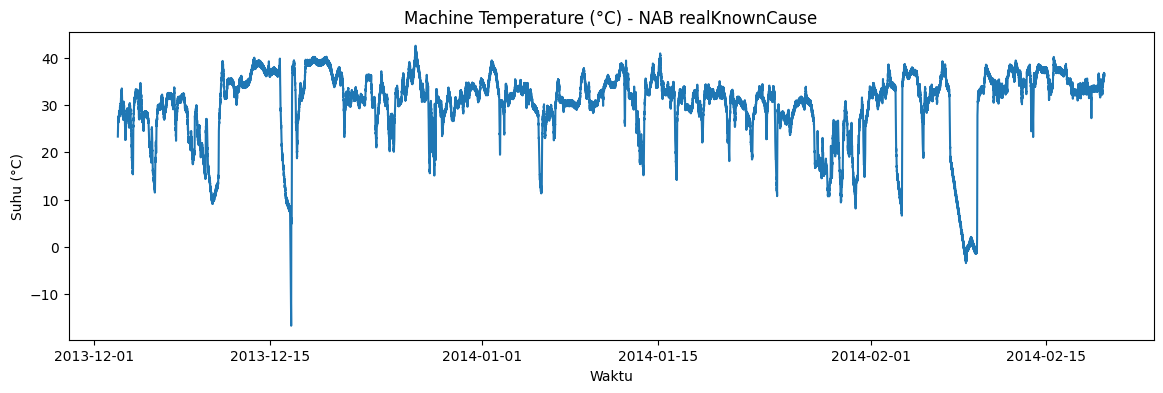

In [37]:
# konversi ke Celsius (asumsi Fahrenheit)
df_machine['value_c'] = (df_machine['value'] - 32) * 5/9
df_machine['timestamp'] = pd.to_datetime(df_machine['timestamp'])

plt.figure(figsize=(14,4))
plt.plot(df_machine['timestamp'], df_machine['value_c'])
plt.title('Machine Temperature (°C) - NAB realKnownCause')
plt.xlabel('Waktu')
plt.ylabel('Suhu (°C)')
plt.show()

**DATA 5**

In [57]:
!mkdir -p data/raw/uah_driveset
!unzip -o D1_DATA_ONLY.zip -d data/raw/uah_driveset

Archive:  D1_DATA_ONLY.zip
   creating: data/raw/uah_driveset/D1_DATA_ONLY/
   creating: data/raw/uah_driveset/D1_DATA_ONLY/20151110175712-16km-D1-NORMAL1-SECONDARY/
  inflating: data/raw/uah_driveset/D1_DATA_ONLY/20151110175712-16km-D1-NORMAL1-SECONDARY/EVENTS_INERTIAL.txt  
  inflating: data/raw/uah_driveset/D1_DATA_ONLY/20151110175712-16km-D1-NORMAL1-SECONDARY/EVENTS_LIST_LANE_CHANGES.txt  
  inflating: data/raw/uah_driveset/D1_DATA_ONLY/20151110175712-16km-D1-NORMAL1-SECONDARY/EVENTS_LIST_LANE_CHANGES.txt~  
  inflating: data/raw/uah_driveset/D1_DATA_ONLY/20151110175712-16km-D1-NORMAL1-SECONDARY/PROC_LANE_DETECTION.txt  
  inflating: data/raw/uah_driveset/D1_DATA_ONLY/20151110175712-16km-D1-NORMAL1-SECONDARY/PROC_OPENSTREETMAP_DATA.txt  
  inflating: data/raw/uah_driveset/D1_DATA_ONLY/20151110175712-16km-D1-NORMAL1-SECONDARY/PROC_VEHICLE_DETECTION.txt  
  inflating: data/raw/uah_driveset/D1_DATA_ONLY/20151110175712-16km-D1-NORMAL1-SECONDARY/RAW_ACCELEROMETERS.txt  
  inflating: dat

In [59]:
with open('data/raw/uah_driveset/D1_DATA_ONLY/20151111132348-25km-D1-DROWSY-MOTORWAY/SEMANTIC_FINAL.txt') as f:
    print(f.read())

13
23
48
97
113
4.3
15
13
39
38
25 km
10.0
6.9
3.8
6.3
1
0
5
-3.3
10.2
14.4
8954431.0
939
9
-536.4
0.0
0.7
0.4
100.0
100.0
0.0
0.0
0.0
0.0
0
0
0
3
2
1
2
2
0
67.3
100.0
38.1
69.0
26.3
43.0
97.3
97.3
0.324
0.557
0.119


**DATA 6**

In [45]:
!kaggle datasets download -d crailtap/taxi-trajectory
!mkdir -p data/raw/porto_taxi
!unzip -o taxi-trajectory.zip -d data/raw/porto_taxi

Dataset URL: https://www.kaggle.com/datasets/crailtap/taxi-trajectory
License(s): unknown
100% 515M/515M [00:10<00:00, 51.6MB/s]

Archive:  taxi-trajectory.zip
  inflating: data/raw/porto_taxi/train.csv  


In [47]:
!ls -lh data/raw/porto_taxi

total 1.9G
-rw-r--r-- 1 root root 1.9G Sep 29  2019 train.csv


In [48]:
df_taxi_sample = pd.read_csv('data/raw/porto_taxi/train.csv', nrows=5)
df_taxi_sample

,TRIP_ID,CALL_TYPE,ORIGIN_CALL,ORIGIN_STAND,TAXI_ID,TIMESTAMP,DAY_TYPE,MISSING_DATA,POLYLINE
0,1372636858620000589,C,NaN,NaN,20000589,1372636858,A,False,"[[-8.618643,41.141412],[-8.618499,41.141376],[..."
1,1372637303620000596,B,NaN,7.0,20000596,1372637303,A,False,"[[-8.639847,41.159826],[-8.640351,41.159871],[..."
2,1372636951620000320,C,NaN,NaN,20000320,1372636951,A,False,"[[-8.612964,41.140359],[-8.613378,41.14035],[-..."
3,1372636854620000520,C,NaN,NaN,20000520,1372636854,A,False,"[[-8.574678,41.151951],[-8.574705,41.151942],[..."
4,1372637091620000337,C,NaN,NaN,20000337,1372637091,A,False,"[[-8.645994,41.18049],[-8.645949,41.180517],[-..."


In [49]:
df_taxi = pd.read_csv('data/raw/porto_taxi/train.csv', nrows=50000)
df_taxi.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 9 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   TRIP_ID       50000 non-null  int64  
 1   CALL_TYPE     50000 non-null  object 
 2   ORIGIN_CALL   10784 non-null  float64
 3   ORIGIN_STAND  24434 non-null  float64
 4   TAXI_ID       50000 non-null  int64  
 5   TIMESTAMP     50000 non-null  int64  
 6   DAY_TYPE      50000 non-null  object 
 7   MISSING_DATA  50000 non-null  bool   
 8   POLYLINE      50000 non-null  object 
dtypes: bool(1), float64(2), int64(3), object(3)
memory usage: 3.1+ MB


In [50]:
import ast

# convert kolom POLYLINE dari teks jadi list beneran
df_taxi['polyline_parsed'] = df_taxi['POLYLINE'].apply(ast.literal_eval)

# hitung jumlah titik koordinat per trip
df_taxi['n_points'] = df_taxi['polyline_parsed'].apply(len)

# durasi trip dalam detik (tiap titik berjarak 15 detik)
df_taxi['duration_sec'] = df_taxi['n_points'] * 15

df_taxi[['TRIP_ID', 'n_points', 'duration_sec']].describe()

,TRIP_ID,n_points,duration_sec
count,5.000000e+04,50000.000000,50000.000000
mean,1.373078e+18,47.835540,717.533100
std,2.494146e+14,44.362336,665.435046
min,1.372637e+18,0.000000,0.000000
25%,1.372867e+18,28.000000,420.000000
50%,1.373068e+18,41.000000,615.000000
75%,1.373291e+18,58.000000,870.000000
max,1.373533e+18,2516.000000,37740.000000


**DATA 7**

In [52]:
import requests

# Koordinat Jakarta
lat, lon = -6.2088, 106.8456

url = "https://power.larc.nasa.gov/api/temporal/hourly/point"
params = {
    "parameters": "T2M,ALLSKY_SFC_SW_DWN",
    "community": "RE",
    "longitude": lon,
    "latitude": lat,
    "start": "20240101",
    "end": "20240107",
    "format": "JSON"
}

response = requests.get(url, params=params)
data = response.json()
print(response.status_code)

200


In [53]:
temp_data = data['properties']['parameter']['T2M']
solar_data = data['properties']['parameter']['ALLSKY_SFC_SW_DWN']

df_nasa = pd.DataFrame({
    'timestamp': temp_data.keys(),
    'temp_c': temp_data.values(),
    'solar_radiation': solar_data.values()
})

df_nasa['timestamp'] = pd.to_datetime(df_nasa['timestamp'], format='%Y%m%d%H')
df_nasa.head(10)

,timestamp,temp_c,solar_radiation
0,2024-01-01 00:00:00,27.60,0.00
1,2024-01-01 01:00:00,27.57,0.00
2,2024-01-01 02:00:00,27.59,0.00
3,2024-01-01 03:00:00,27.63,0.00
4,2024-01-01 04:00:00,27.64,0.00
5,2024-01-01 05:00:00,27.66,0.00
6,2024-01-01 06:00:00,28.01,62.17
7,2024-01-01 07:00:00,28.68,217.02
8,2024-01-01 08:00:00,29.19,393.50
9,2024-01-01 09:00:00,29.44,512.33


In [54]:
df_nasa[['temp_c', 'solar_radiation']].describe()

,temp_c,solar_radiation
count,168.000000,168.000000
mean,28.249643,165.860476
std,1.224953,231.064008
min,25.980000,0.000000
25%,27.427500,0.000000
50%,28.055000,5.750000
75%,29.040000,308.225000
max,31.310000,754.420000


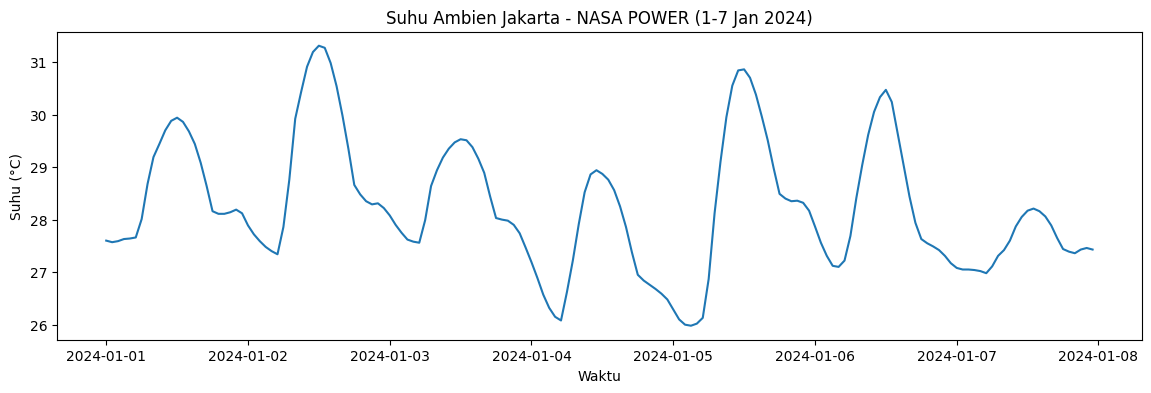

In [55]:
plt.figure(figsize=(14,4))
plt.plot(df_nasa['timestamp'], df_nasa['temp_c'])
plt.title('Suhu Ambien Jakarta - NASA POWER (1-7 Jan 2024)')
plt.xlabel('Waktu')
plt.ylabel('Suhu (°C)')
plt.show()